# BeeHappy — Data Foundation

Three tables of real beehive sensor data go in. One model-ready dataframe comes out.

Roughly 4 hours. Exercises build on each other, so do them in order.

## How this notebook works

If you haven't used a notebook before, the mental model is different from a script.

- **Shortcuts**:
  - `Shift + Enter` run the current cell, select below
  - `Ctrl + Enter` run selected cells
  - `Alt + Enter` run the current cell, insert below
  - `Ctrl + S` save and checkpoint

- **State carries forward.** Variables, imports, and dataframes you create in one cell
  are still there in every cell you run after it.

  - For example: `DATABASE_URL` in the setup cell below is available in Exercise 0
  because that cell ran first.

- **Order of execution matters, not order on the page.** If you go back and re-run an
  earlier cell, or run cells out of order, the notebook's state reflects whatever you
  ran *last*, which may not match top-to-bottom reading order. The number in `[ ]` to
  the left of a code cell tells you the order it actually ran in — if those numbers
  aren't ascending top to bottom, your state and the page have diverged.

- **When in doubt, restart.** If variables seem stale or wrong, use the "Restart
  Kernel" action and run all cells again from the top in order — that guarantees the
  state matches what's on the page. This notebook is meant to be run top to bottom, once,
  in order. The exercises build on each other's variables.

- **Code / Markdown**: you can add your own comments / notes using a Markdown block
(as how this block is being written). The added cells using Alt + Enter will be `Code`
by default, change it to Markdown by navigating to the menu bar and find the Code with
 an arrow pointing downward. Select Markdown.

## The target

Use the cleaned data to answer the question: **which material is the best among the three beehives?**

- This means **producing a file** that contains all the information from all sensors with an **easy to read format**.
- Then visualize the data by **plotting them**, and use this information to answer the question.

The data should have: one row per hive per hour, with these columns. 

| Column | Meaning |
|---|---|
| `beehive_id`, `hive_name` | which hive |
| `hour` | the hour, UTC |
| `brood_temp_c1/c2/c3` | brood chamber, three probes |
| `food_temp`, `food_humidity` | food chamber |
| `outside_temp`, `outside_humidity`, `outside_wind_speed`, `outside_wind_dir`, `outside_uv_index`, `outside_pressure_pa`, `outside_light`, `outside_rain` | ambient |
| `hour_local`, `month`, `dayofweek` | calendar, **Europe/Berlin** |

The file you write into will be validated by `workshop/validate_features.py`, which enforces the exact schema, so match the names.

Write the dataframe to `workshop/out/features_hourly.parquet`, then run:

```bash
uv run python workshop/validate_features.py workshop/out/features_hourly.parquet
```

In [ ]:
import os
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

REPO = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
OUT = REPO / "workshop" / "out"
RAW = OUT / "raw"          # your extract lands here
RAW.mkdir(parents=True, exist_ok=True)

# The connection string comes from .env, which is gitignored. The role is
# read-only: you cannot damage the database, only wait a long time for a query
# you did not mean to run.
load_dotenv(REPO / ".env")
DATABASE_URL = os.environ["DATABASE_URL"]
print("database:", DATABASE_URL)
print("extract ->", RAW)

---
## Exercise 0 — Extract (30 min)

The source is a Postgres database with three tables:

| Table | What it is |
|---|---|
| `beehives` | the hives |
| `sensors` | the devices, and which hive each belongs to |
| `data` | every reading, one row per measurement |

**Tasks:**
1. Open **one** connection using `DATABASE_URL`. (already implemented in the `with...` line)
2. Pull `beehives` and `sensors` whole. They are tiny.
3. Pull the **last three months** of `data`. It is a large table and most of it is
   older than that, so **filter in SQL** using the column name `ts`.
4. Persist all three to `workshop/out/raw/` in whatever format you prefer: Parquet,
   CSV, a local SQLite file, your choice. Be ready to say why you chose it.
5. Close the connection. Keep working from the dataframes you already have — the
   parquet copy exists so you don't have to hit the database again, not so you have to
   reload from it. (already implemented in the `with...` line)

**Deliverable:** `beehives`, `sensors` and `data` in memory, persisted to
`workshop/out/raw/`, with row counts and the exact period you pulled printed out.

A pattern worth reusing: keep your queries in a dict and loop once. Fill in the SQL
and the loop in the cell below. `frames["beehives"]`, `frames["sensors"]`,
`frames["data"]`. Persist each with (`frames[...].to_{your_choice_of_format}(...)`);
you don't need to reload from the database afterward to keep working.

*You should hit the database once, today. If you find yourself re-running a query
later to get a dataframe back, the extract step is not finished.*

*Mind your format. `ts` is a timestamp and `value` is a float — CSV will hand both back
to you as strings unless you tell it otherwise.*

In [21]:
# TODO: extract once, persist, read back.
import pandas as pd
import psycopg

# one entry per table: table name -> the SQL that pulls it
queries = {
    "beehives": "SELECT * FROM beehives",
    "sensors":  "SELECT * FROM sensors",
    "data":     "SELECT * FROM data WHERE ts >= now() - INTERVAL '3 months'",  # last three months; filter in SQL, not in pandas
}

frames = {}
with psycopg.connect(DATABASE_URL, connect_timeout=30) as conn:
    # put the fetch below in a for loop over queries.items()
    with conn.cursor() as cur:
        # looping
        for key, value in queries.items():
            cur.execute(value)
            # cur.fetchall() gives the rows; cur.description gives the column names
            frames[key] = pd.DataFrame(cur.fetchall(), columns=[c.name for c in cur.description])
            #persist the Dataframe by using to_parquet, to_csv, to_pickel, ...
            frames[key].to_parquet(RAW / f'{key}.parquet')

Read back from disk. Everything downstream works from these, so the rest of the
day is reproducible and needs no network.

In [248]:
beehives = pd.read_parquet(RAW / "beehives.parquet")
sensors  = pd.read_parquet(RAW / "sensors.parquet")
data     = pd.read_parquet(RAW / "data.parquet")

---
## Exercise 1 — Profile (30 min)

**Questions:**
1. What is one row of `data`? What makes a row unique?
2. How many measurements exist, and which devices produce which?
3. What period is covered, how many days of data, and are there NULLs?
4. How do `sensors` and `beehives` relate to `data`?

**Deliverable:** a short written profile, plus at least one thing that surprises you.

A pattern worth reusing: run one view per cell — the notebook shows the result.

After running these, you should be able to answer the four questions in a short written profile, plus name one surprise.

*Hint: `data` is **long** — one row per measurement, not per device reading.*

In [23]:
# first rows: one measurement per row — columns, and what a unique row looks like
data.head()

,reading_id,sensor_id,beehive_id,measurement_unit,ts,value
0,2072737,8,1,tempC3,2026-06-28 12:22:52.471,37.3
1,2072738,8,1,tempC1,2026-06-28 12:22:52.471,35.5
2,2072739,8,1,tempC2,2026-06-28 12:22:52.471,35.7
3,2072776,8,1,tempC3,2026-06-28 12:22:52.471,37.3
4,2072777,8,1,tempC1,2026-06-28 12:22:52.471,35.5


In [10]:
# types: ts should be a timestamp, value a float
data.dtypes

reading_id                   int64
sensor_id                    int64
beehive_id                   int64
measurement_unit               str
ts                  datetime64[us]
value                      float64
dtype: object

In [24]:
# how many readings of each measurement kind exist
data["measurement_unit"].value_counts()

measurement_unit
temperature         78760
relativeHumidity    78760
lightIntensity      39381
rainGauge           39381
pressure            39381
windDirection       39381
uvIndex             39381
windSpeed           39381
tempC3              39377
tempC1              39377
tempC2              39377
Name: count, dtype: int64

In [25]:
# the extract's time window, not the calendar
data["ts"].min(), data["ts"].max()

(Timestamp('2026-06-28 12:22:52.471000'),
 Timestamp('2026-09-28 12:14:42.666000'))

In [26]:
# missing values in the reading itself — if the count is zero, does that mean nothing is missing?
data["value"].isna()

0         False
1         False
2         False
3         False
4         False
          ...  
511932    False
511933    False
511934    False
511935    False
511936    False
Name: value, Length: 511937, dtype: bool

In [27]:
data["value"].isna().sum()

np.int64(0)

In [28]:
# the device catalog: how many devices, of which types, on which hives
sensors

,sensor_id,beehive_id,sensor_name,sensor_type,measurement_units,installation_date,last_seen,is_active
0,1,1,LoRa-2CF7F1C0613005BC,LoRaWAN SenseCAP-S2120,"lightIntensity,rainGauge,relativeHumidity,temp...",2025-04-14,2025-06-13 13:51:12.935,True
1,2,2,LoRa-2CF7F1C0613005BC,LoRaWAN SenseCAP-S2120,"lightIntensity,rainGauge,relativeHumidity,temp...",2025-04-14,2025-06-13 13:51:12.935,True
2,3,3,LoRa-2CF7F1C0613005BC,LoRaWAN SenseCAP-S2120,"lightIntensity,rainGauge,relativeHumidity,temp...",2025-04-14,2025-06-13 13:51:12.935,True
3,4,1,LoRa-A840411F645AE815,LoRaWAN Dragino-S31-LB,"temperature,relativeHumidity",2025-04-14,2025-06-13 13:58:44.800,True
4,5,3,LoRa-A8404138A188669C,LoRaWAN Dragino-S31-LB,"temperature,relativeHumidity",2025-04-14,2025-06-13 13:44:39.205,True
5,6,2,LoRa-A84041CC625AE81E,LoRaWAN Dragino-S31-LB,"temperature,relativeHumidity",2025-04-14,2025-06-13 13:55:55.762,True
6,7,3,LoRa-A8404160C85A7A7B,LoRaWAN Dragino-D23-LB,"tempC3,tempC1,tempC2",2025-04-14,2025-06-13 13:09:35.952,True
7,8,1,LoRa-A84041892E5A7A68,LoRaWAN Dragino-D23-LB,"tempC3,tempC1,tempC2",2025-04-14,2025-06-13 13:34:31.630,True
8,9,2,LoRa-A840419521864618,LoRaWAN Dragino-D23-LB,"tempC3,tempC1,tempC2",2025-04-14,2025-06-13 13:54:12.964,True


In [243]:
# print all measurement units from sensors at line index 0
sensors.loc[0, "measurement_units"]

'lightIntensity,rainGauge,relativeHumidity,temperature,pressure,windDirection,uvIndex,windSpeed'

In [16]:
beehives

,beehive_id,name,location,installation_date,last_inspection_date,notes
0,1,Beehive No.1,"(49.15182633037482,9.215298005933729)",2025-04-14,2025-04-14,"Larry is standing alone, he needs some friends"
1,2,Beehive No.2,"(49.15184249515977,9.21529330883642)",2025-04-14,2025-04-14,TamTam is the middle Sandwhich child
2,3,Beehive No.3,"(49.151846188225065,9.215281522540364)",2025-04-14,2025-04-14,BonBon is the smallest yet most active


In [29]:
data["ts"].max() - data["ts"].min()

Timedelta('91 days 23:51:50.195000')

Write the profile in the following block, print out results from functions in the block

# Written profile
1. One row of data consists of reading_id	sensor_id	beehive_id	measurement_unit	ts	value. It is unique when there are no 2 rows that have the exact same value in any of those columns.
2. Eleven types of measurement
  
  - LoRaWAN Dragino-S31-LB measures temperature,relativeHumidity
  - LoRaWAN Dragino-D23-LB measures tempC3,tempC1,tempC2
  - LoRaWAN SenseCAP-S2120 measures lightIntensity, rainGauge, relativeHumidity, temperature, pressure, windDirection, uvIndex, windSpeed

3. From 2026-06-28 12:22:52.471000 to 2026-09-28 12:14:42.666000: 91 days (almost 92 days). No NULLs
4. By sensor_id	and beehive_id

---
## Exercise 2 — Deduplicate (30 min)

**Questions:**
1. Which combination of columns *should* uniquely identify a row?
2. Does it? By how much?
3. Where duplicates exist, do they agree on `value`? This decides whether you can
   simply drop them or have to arbitrate between conflicting readings.

**Deliverable:** `data` at one row per real measurement, and a number for how much
you removed.

A pattern worth reusing: name the grain, then let pandas tell you whether it holds.
Fill `KEY` in the cell below.

After this, `data` should be one row per real measurement, and you should have a number for how much you removed.

*`reading_id` is a database row id. Use it to prove what you find is real and not an
artifact of your own query.*

In [38]:
# TODO: find the true grain, quantify the redundancy, check for conflicts, dedup.
# columns that should identify one real measurement — fill this in from question 1
KEY = ["sensor_id", "measurement_unit", "ts"]

In [39]:
# rows you started with vs how many distinct keys exist
before = len(data)
distinct = len(data.drop_duplicates(subset=KEY))
print(f"Number of rows before dedup: {before} and after: {distinct}.")

Number of rows before dedup: 511937 and after: 392344.


In [52]:
# how many copies the worst key has
data.groupby(KEY).size().max()

np.int64(70)

In [54]:
# do copies of the same key disagree on value?
# 0 => exact copies, safe to drop; >0 => you have to pick a winner
data.groupby(KEY)["value"].nunique()

sensor_id  measurement_unit  ts                     
1          lightIntensity    2026-06-28 12:24:36.630    1
                             2026-06-28 12:34:40.928    1
                             2026-06-28 12:44:45.206    1
                             2026-06-28 12:54:49.495    1
                             2026-06-28 13:05:08.913    1
                                                       ..
9          tempC3            2026-09-28 10:37:59.116    1
                             2026-09-28 10:57:58.856    1
                             2026-09-28 11:17:58.622    1
                             2026-09-28 11:37:58.366    1
                             2026-09-28 11:57:58.105    1
Name: value, Length: 392344, dtype: int64

In [45]:
(data.groupby(KEY)["value"].nunique() > 1).sum()

np.int64(0)

In [49]:
# reading_id is a database row id, not part of the measurement
# pick one duplicated key and count its reading_ids — different ids means real INSERTs
data.groupby(KEY)["reading_id"].nunique()

sensor_id  measurement_unit  ts                     
1          lightIntensity    2026-06-28 12:24:36.630    1
                             2026-06-28 12:34:40.928    1
                             2026-06-28 12:44:45.206    1
                             2026-06-28 12:54:49.495    1
                             2026-06-28 13:05:08.913    1
                                                       ..
9          tempC3            2026-09-28 10:37:59.116    2
                             2026-09-28 10:57:58.856    2
                             2026-09-28 11:17:58.622    2
                             2026-09-28 11:37:58.366    2
                             2026-09-28 11:57:58.105    2
Name: reading_id, Length: 392344, dtype: int64

In [95]:
# then keep one row per key
data = data.drop_duplicates(subset=KEY)

In [96]:
# if you want the index column to be incremental
data_reindexed = data.reset_index()

---
## Exercise 3 — Reshape and join (60 min)

Attach context: which hive a reading belongs to, and what the weather was doing.

**Tasks:**
1. Map `sensor_type` to a role using `ROLE` below. Hardware names are given; you should not have to reverse-engineer them.
2. **Before any join**, look at the weather rows in `sensors`. How many rows? How many distinct devices?
3. Merge `beehive_id` and `role` onto `data`. Print `len(data)` before and after.
4. Split into hive readings vs weather readings. State the grain of each.
5. If a row count changed, is that change correct?

**Deliverable:** `hive_rows` and `weather_rows`, each with a grain you can state.

A pattern worth reusing: inspect the dimension table before you join it. The `ROLE`
map is in the first cell; then assign the merge and split.

After this you should have two frames whose grains you can state, and a written note on whether the merge changed `len(data)` and why.

*Take the row-count question seriously. There is something in `sensors` that makes a careless join here silently wrong, and it will not raise an error.*

In [245]:
# TODO: map roles, inspect weather in sensors before you join.
# hardware names -> roles you will use to split hive vs ambient
ROLE = {
    "LoRaWAN Dragino-S31-LB": "food_chamber",
    "LoRaWAN Dragino-D23-LB": "brood_chamber",
    "LoRaWAN SenseCAP-S2120": "weather",
}
sensors = sensors.assign(role=sensors["sensor_type"].map(ROLE))

# look at weather in sensors BEFORE you join — row count vs distinct devices
sensors[sensors["role"] == "weather"]

,sensor_id,beehive_id,sensor_name,sensor_type,measurement_units,installation_date,last_seen,is_active,role
0,1,1,LoRa-2CF7F1C0613005BC,LoRaWAN SenseCAP-S2120,"lightIntensity,rainGauge,relativeHumidity,temp...",2025-04-14,2025-06-13 13:51:12.935,True,weather
1,2,2,LoRa-2CF7F1C0613005BC,LoRaWAN SenseCAP-S2120,"lightIntensity,rainGauge,relativeHumidity,temp...",2025-04-14,2025-06-13 13:51:12.935,True,weather
2,3,3,LoRa-2CF7F1C0613005BC,LoRaWAN SenseCAP-S2120,"lightIntensity,rainGauge,relativeHumidity,temp...",2025-04-14,2025-06-13 13:51:12.935,True,weather
3,4,1,LoRa-A840411F645AE815,LoRaWAN Dragino-S31-LB,"temperature,relativeHumidity",2025-04-14,2025-06-13 13:58:44.800,True,food_chamber
4,5,3,LoRa-A8404138A188669C,LoRaWAN Dragino-S31-LB,"temperature,relativeHumidity",2025-04-14,2025-06-13 13:44:39.205,True,food_chamber
5,6,2,LoRa-A84041CC625AE81E,LoRaWAN Dragino-S31-LB,"temperature,relativeHumidity",2025-04-14,2025-06-13 13:55:55.762,True,food_chamber
6,7,3,LoRa-A8404160C85A7A7B,LoRaWAN Dragino-D23-LB,"tempC3,tempC1,tempC2",2025-04-14,2025-06-13 13:09:35.952,True,brood_chamber
7,8,1,LoRa-A84041892E5A7A68,LoRaWAN Dragino-D23-LB,"tempC3,tempC1,tempC2",2025-04-14,2025-06-13 13:34:31.630,True,brood_chamber
8,9,2,LoRa-A840419521864618,LoRaWAN Dragino-D23-LB,"tempC3,tempC1,tempC2",2025-04-14,2025-06-13 13:54:12.964,True,brood_chamber


In [99]:
# TODO: merge, print len before and after.
# attach hive + role to every reading; print len before and after

# select the important columns from the sensors table
SENSOR_COLUMNS = ["sensor_id", "beehive_id", "role"]

# decide on which column(s) you will perform the merge on
ON_COLUMNS = ["sensor_id", "beehive_id"]

# merge type (left, right, inner, outer)
MERGE_TYPE = "left"

data = data.merge(sensors[SENSOR_COLUMNS], on=ON_COLUMNS, how=MERGE_TYPE)

In [102]:
# TODO: split into hive_rows and weather_rows. State the grain.
# For weather readings: select the lines that has value "weather" in the column "role"
weather_rows = data[data["role"] == "weather"]

# For weather readings: select the lines that has value NOT "weather" in the column "role"
hive_rows = data[data["role"] != "weather"]

In [78]:
weather_rows["sensor_id"].unique()

array([1, 2, 3])

In [ ]:
weather_rows["sensor_id"].unique()

In [84]:
weather_rows_deduped = weather_rows.drop_duplicates(subset=["measurement_unit", "ts"])
print(f"Number of rows in weather datafram before: {weather_rows.shape[0]} and after dedup: {weather_rows_deduped.shape[0]}")

Number of rows in weather datafram before: 310152 and after dedup: 103384


---
## Exercise 4 — Align time and handle gaps (60 min)

Devices report on their own schedules and their timestamps never line up, so nothing
can be joined on an exact time. Put everything on one clock.

**Do this:**
1. Floor `ts` to the hour. Look at `ts` vs `hour`. Confirm devices report at least that often — the target is already hourly.
2. `groupby` + `mean` — still long: one row per hive-hour-measurement. Look at the index.
3. `unstack` so each measurement is a column. Hive grain: `(beehive_id, hour)`. Repeat the three verbs for weather; grain: `(hour,)`.
4. Build a **complete** index of every hive and every hour in the extract window (`data["ts"].min()` to `.max()`, not one device’s coverage). Reindex the hive frame onto it. How many hive-hours were absent?
5. Look at gap lengths before choosing a treatment.
6. Join weather on `hour`. Print `len` before and after. Then interpolate, forward-fill, or leave NaN — write down the rule.

**Deliverable:** `features`, one row per hive-hour, with a stated gap policy.

A pattern worth reusing: one verb at a time, then look at the shape. Work through
the cells in order.

After this, `features` should have one row per hive-hour, weather attached, and a written gap rule.

*This is where the missing data actually is. There are no NULLs in this dataset — rows
for hours a device did not report simply do not exist. Only a complete index reveals them.*

*Build the index from the window you extracted, not from what one device happens to
cover. If a hive was silent for the last week of your three months, its rows end early
and the grid should not — that silence is the thing you are trying to see.*

In [104]:
# TODO: floor ts to hour on hive_rows; look at ts vs hour.
# 1. one clock: every ts belongs to an hour
hive_rows = hive_rows.assign(hour=hive_rows["ts"].dt.floor("h"))
hive_rows[["ts", "hour"]].head()

,ts,hour
0,2026-06-28 12:22:52.471,2026-06-28 12:00:00
1,2026-06-28 12:22:52.471,2026-06-28 12:00:00
2,2026-06-28 12:22:52.471,2026-06-28 12:00:00
3,2026-06-28 12:23:27.991,2026-06-28 12:00:00
4,2026-06-28 12:23:27.991,2026-06-28 12:00:00


In [246]:
hive_rows.shape

(82192, 8)

In [106]:
# TODO: groupby + mean (still long). Look at the index.
# 2. still long: one row per hive-hour-measurement, mean if a device reported twice
hive_h = hive_rows.groupby(["beehive_id", "hour", "measurement_unit"])["value"].mean()
hive_h.head()

beehive_id  hour                 measurement_unit
1           2026-06-28 12:00:00  relativeHumidity    62.25
                                 tempC1              35.65
                                 tempC2              35.75
                                 tempC3              37.40
                                 temperature         35.25
Name: value, dtype: float64

In [107]:
# TODO: unstack hive to wide. Repeat the three verbs for weather.
# 3. wide: each measurement becomes a column
hive_h = hive_h.unstack("measurement_unit")
hive_h.head()

measurement_unit                relativeHumidity     tempC1     tempC2     tempC3  temperature
beehive_id hour                                                                               
1          2026-06-28 12:00:00         62.250000  35.650000  35.750000  37.400000    35.250000
           2026-06-28 13:00:00         60.500000  36.100000  36.300000  37.766667    35.566667
           2026-06-28 14:00:00         61.666667  36.033333  36.866667  38.533333    35.800000
           2026-06-28 15:00:00         60.833333  35.766667  37.500000  40.866667    35.900000
           2026-06-28 16:00:00         60.900000  35.700000  37.333333  41.366667    35.833333

In [141]:
# weather is the same verbs, grain is (hour,) not (beehive_id, hour)
# ... then add_prefix("outside_")
weather_rows = weather_rows.assign(hour=weather_rows["ts"].dt.floor("h"))
weather_h = weather_rows.groupby(["beehive_id", "hour", "measurement_unit"])["value"].mean()
weather_h.head()

beehive_id  hour                 measurement_unit
1           2026-06-28 12:00:00  lightIntensity       94460.00
                                 pressure            100017.50
                                 rainGauge                0.00
                                 relativeHumidity        27.75
                                 temperature             38.85
Name: value, dtype: float64

In [142]:
weather_h = weather_h.unstack("measurement_unit").add_prefix("outside_")

In [115]:
# TODO: build the full grid and reindex hive_h onto it.
START_TIME_H = data["ts"].min().floor("h")
END_TIME_H = data["ts"].max().floor("h")

hours = pd.date_range(START_TIME_H, END_TIME_H, freq="h")
hours

DatetimeIndex(['2026-06-28 12:00:00', '2026-06-28 13:00:00', '2026-06-28 14:00:00', '2026-06-28 15:00:00', '2026-06-28 16:00:00',
               '2026-06-28 17:00:00', '2026-06-28 18:00:00', '2026-06-28 19:00:00', '2026-06-28 20:00:00', '2026-06-28 21:00:00',
               ...
               '2026-09-28 03:00:00', '2026-09-28 04:00:00', '2026-09-28 05:00:00', '2026-09-28 06:00:00', '2026-09-28 07:00:00',
               '2026-09-28 08:00:00', '2026-09-28 09:00:00', '2026-09-28 10:00:00', '2026-09-28 11:00:00', '2026-09-28 12:00:00'],
              dtype='datetime64[us]', length=2209, freq='h')

In [118]:
# complete grid from the extract window

grid  = pd.MultiIndex.from_product(
    [beehives["beehive_id"], hours], names=["beehive_id", "hour"]
)
grid

MultiIndex([(1, '2026-06-28 12:00:00'),
            (1, '2026-06-28 13:00:00'),
            (1, '2026-06-28 14:00:00'),
            (1, '2026-06-28 15:00:00'),
            (1, '2026-06-28 16:00:00'),
            (1, '2026-06-28 17:00:00'),
            (1, '2026-06-28 18:00:00'),
            (1, '2026-06-28 19:00:00'),
            (1, '2026-06-28 20:00:00'),
            (1, '2026-06-28 21:00:00'),
            ...
            (3, '2026-09-28 03:00:00'),
            (3, '2026-09-28 04:00:00'),
            (3, '2026-09-28 05:00:00'),
            (3, '2026-09-28 06:00:00'),
            (3, '2026-09-28 07:00:00'),
            (3, '2026-09-28 08:00:00'),
            (3, '2026-09-28 09:00:00'),
            (3, '2026-09-28 10:00:00'),
            (3, '2026-09-28 11:00:00'),
            (3, '2026-09-28 12:00:00')],
           names=['beehive_id', 'hour'], length=6627)

In [183]:
features = hive_h.reindex(grid)
features

measurement_unit                relativeHumidity     tempC1     tempC2     tempC3  temperature
beehive_id hour                                                                               
1          2026-06-28 12:00:00         62.250000  35.650000  35.750000  37.400000    35.250000
           2026-06-28 13:00:00         60.500000  36.100000  36.300000  37.766667    35.566667
           2026-06-28 14:00:00         61.666667  36.033333  36.866667  38.533333    35.800000
           2026-06-28 15:00:00         60.833333  35.766667  37.500000  40.866667    35.900000
           2026-06-28 16:00:00         60.900000  35.700000  37.333333  41.366667    35.833333
...                                          ...        ...        ...        ...          ...
3          2026-09-28 08:00:00         55.966667  25.533333  20.866667  20.633333    30.800000
           2026-09-28 09:00:00         57.300000  26.066667  21.933333  22.166667    30.966667
           2026-09-28 10:00:00         58.666667  27.066667  23.466667  24.266667    31.333333
           2026-09-28 11:00:00         60.200000  28.200000  27.100000  28.900000    31.800000
           2026-09-28 12:00:00         59.000000  29.300000  29.500000  31.500000    32.500000

[6627 rows x 5 columns]

In [189]:
# TODO: measure gap lengths before choosing a treatment.
# gap lengths per hive — minutes vs days changes the policy
hive_h.reset_index()

measurement_unit,beehive_id,hour,relativeHumidity,tempC1,tempC2,tempC3,temperature
0,1,2026-06-28 12:00:00,62.250000,35.650000,35.750000,37.400000,35.250000
1,1,2026-06-28 13:00:00,60.500000,36.100000,36.300000,37.766667,35.566667
2,1,2026-06-28 14:00:00,61.666667,36.033333,36.866667,38.533333,35.800000
3,1,2026-06-28 15:00:00,60.833333,35.766667,37.500000,40.866667,35.900000
4,1,2026-06-28 16:00:00,60.900000,35.700000,37.333333,41.366667,35.833333
...,...,...,...,...,...,...,...
6499,3,2026-09-28 08:00:00,55.966667,25.533333,20.866667,20.633333,30.800000
6500,3,2026-09-28 09:00:00,57.300000,26.066667,21.933333,22.166667,30.966667
6501,3,2026-09-28 10:00:00,58.666667,27.066667,23.466667,24.266667,31.333333
6502,3,2026-09-28 11:00:00,60.200000,28.200000,27.100000,28.900000,31.800000


In [133]:
# There is the difference between the df reindexed with a time range and the the original df
# We need to check the maximum gap in the hour between each record for each beehive.
hive_h.reset_index().groupby("beehive_id")["hour"].diff().max()

Timedelta('0 days 17:00:00')

In [146]:
weather_h

measurement_unit                outside_lightIntensity  outside_pressure  outside_rainGauge  outside_relativeHumidity  \
beehive_id hour                                                                                                         
1          2026-06-28 12:00:00            94460.000000     100017.500000                0.0                 27.750000   
           2026-06-28 13:00:00            83844.000000      99973.333333                0.0                 28.833333   
           2026-06-28 14:00:00            71507.333333      99913.333333                0.0                 27.166667   
           2026-06-28 15:00:00            43260.166667      99905.000000                0.0                 27.333333   
           2026-06-28 16:00:00            21881.333333      99898.333333                0.0                 29.500000   
...                                                ...               ...                ...                       ...   
3          2026-09-28 08:00:00            13645.666667     100308.333333                0.0                 55.500000   
           2026-09-28 09:00:00            36593.000000     100308.571429                0.0                 48.714286   
           2026-09-28 10:00:00            57880.166667     100283.333333                0.0                 41.833333   
           2026-09-28 11:00:00            57125.000000     100241.666667                0.0                 36.166667   
           2026-09-28 12:00:00            54585.000000     100190.000000                0.0                 33.000000   

measurement_unit                outside_temperature  outside_uvIndex  outside_windDirection  outside_windSpeed  
beehive_id hour                                                                                                 
1          2026-06-28 12:00:00            38.850000         7.625000             184.500000           0.900000  
           2026-06-28 13:00:00            38.533333         6.383333             188.666667           1.050000  
           2026-06-28 14:00:00            39.383333         5.816667             152.000000           1.033333  
           2026-06-28 15:00:00            39.433333         3.533333             222.000000           0.733333  
           2026-06-28 16:00:00            38.016667         1.333333             158.000000           0.716667  
...                                             ...              ...                    ...                ...  
3          2026-09-28 08:00:00            19.016667         0.833333              76.666667           1.033333  
           2026-09-28 09:00:00            21.728571         1.971429              37.571429           0.614286  
           2026-09-28 10:00:00            24.533333         3.950000              25.666667           1.050000  
           2026-09-28 11:00:00            27.750000         3.483333             116.833333           1.166667  
           2026-09-28 12:00:00            30.100000         3.800000              24.000000           0.000000  

[6567 rows x 8 columns]

In [140]:
features

measurement_unit                relativeHumidity     tempC1     tempC2     tempC3  temperature
beehive_id hour                                                                               
1          2026-06-28 12:00:00         62.250000  35.650000  35.750000  37.400000    35.250000
           2026-06-28 13:00:00         60.500000  36.100000  36.300000  37.766667    35.566667
           2026-06-28 14:00:00         61.666667  36.033333  36.866667  38.533333    35.800000
           2026-06-28 15:00:00         60.833333  35.766667  37.500000  40.866667    35.900000
           2026-06-28 16:00:00         60.900000  35.700000  37.333333  41.366667    35.833333
...                                          ...        ...        ...        ...          ...
3          2026-09-28 08:00:00         55.966667  25.533333  20.866667  20.633333    30.800000
           2026-09-28 09:00:00         57.300000  26.066667  21.933333  22.166667    30.966667
           2026-09-28 10:00:00         58.666667  27.066667  23.466667  24.266667    31.333333
           2026-09-28 11:00:00         60.200000  28.200000  27.100000  28.900000    31.800000
           2026-09-28 12:00:00         59.000000  29.300000  29.500000  31.500000    32.500000

[6627 rows x 5 columns]

In [191]:
# TODO: join weather to our feature df on hour, 
# print len before and after, apply a stated gap policy.

# join default is left
features = features.merge(weather_h, on=["beehive_id", "hour"], how="left")

In [ ]:
# then treat gaps with a rule you can defend (interpolate / ffill / leave NaN)


---
## Exercise 5 — Validate and document (30 min)

**Do this:**
1. Add the calendar columns. Careful: `ts` is UTC and the hive is in Germany, so
   "3am" in the data is not 3am at the hive. Germany changes its clocks, so the offset
   is not a constant you can hardcode — check whether your three months cross a change.
2. Rename to the target schema above.
3. Write assertions *before* running the validator — grain, row count, ranges.
4. Write `DATA_DICTIONARY.md`: every column, its unit, and **every decision you made** —
   what window you extracted, what you dropped, what you filled, what you left empty
   and why.
5. Save and validate.

**Deliverable:** `features_hourly.parquet` + `DATA_DICTIONARY.md` passing the validator.

A pattern worth reusing: convert timezone first, then rename to the contract.

After this, `features` should match the target schema, assertions should pass, and the parquet should be on disk. `DATA_DICTIONARY.md` is still yours to write: every column, its unit, and every decision — window, drops, fills, what you left empty and why.

In [193]:
# TODO: reset_index, localise UTC to Europe/Berlin, add calendar columns, print offsets.

# MultiIndex from the grid becomes columns
features = features.reset_index()

In [194]:
# hour is UTC in a naive column; localise then convert. Do not hardcode +01/+02.
local = features["hour"].dt.tz_localize("UTC").dt.tz_convert("Europe/Berlin")

# unique offsets tell you whether this window crossed a clock change
local.dt.strftime("%z").unique()

<ArrowStringArray>
['+0200']
Length: 1, dtype: str

In [195]:
features["hour_local"] = local.dt.hour
features["month"] = local.dt.month
features["dayofweek"] = local.dt.dayofweek

In [196]:
# TODO: rename to the target schema, assert grain, save.

# raw measurement_unit names -> the target schema above
features = features.rename(columns={
    "tempC1": "brood_temp_c1", "tempC2": "brood_temp_c2", "tempC3": "brood_temp_c3",
    "temperature": "food_temp", "relativeHumidity": "food_humidity",
    "outside_temperature": "outside_temp",
    "outside_relativeHumidity": "outside_humidity",
    "outside_windSpeed": "outside_wind_speed",
    "outside_windDirection": "outside_wind_dir",
    "outside_uvIndex": "outside_uv_index",
    "outside_pressure": "outside_pressure_pa",
    "outside_lightIntensity": "outside_light",
    "outside_rainGauge": "outside_rain",
})

In [158]:
# assert grain and completeness before you call the validator
features.to_parquet(OUT / "features_hourly.parquet", index=False)

In [197]:
features

measurement_unit,beehive_id,hour,food_humidity,brood_temp_c1,brood_temp_c2,brood_temp_c3,food_temp,outside_light,outside_pressure_pa,outside_rain,outside_humidity,outside_temp,outside_uv_index,outside_wind_dir,outside_wind_speed,hour_local,month,dayofweek
0,1,2026-06-28 12:00:00,62.250000,35.650000,35.750000,37.400000,35.250000,94460.000000,100017.500000,0.0,27.750000,38.850000,7.625000,184.500000,0.900000,14,6,6
1,1,2026-06-28 13:00:00,60.500000,36.100000,36.300000,37.766667,35.566667,83844.000000,99973.333333,0.0,28.833333,38.533333,6.383333,188.666667,1.050000,15,6,6
2,1,2026-06-28 14:00:00,61.666667,36.033333,36.866667,38.533333,35.800000,71507.333333,99913.333333,0.0,27.166667,39.383333,5.816667,152.000000,1.033333,16,6,6
3,1,2026-06-28 15:00:00,60.833333,35.766667,37.500000,40.866667,35.900000,43260.166667,99905.000000,0.0,27.333333,39.433333,3.533333,222.000000,0.733333,17,6,6
4,1,2026-06-28 16:00:00,60.900000,35.700000,37.333333,41.366667,35.833333,21881.333333,99898.333333,0.0,29.500000,38.016667,1.333333,158.000000,0.716667,18,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6622,3,2026-09-28 08:00:00,55.966667,25.533333,20.866667,20.633333,30.800000,13645.666667,100308.333333,0.0,55.500000,19.016667,0.833333,76.666667,1.033333,10,9,0
6623,3,2026-09-28 09:00:00,57.300000,26.066667,21.933333,22.166667,30.966667,36593.000000,100308.571429,0.0,48.714286,21.728571,1.971429,37.571429,0.614286,11,9,0
6624,3,2026-09-28 10:00:00,58.666667,27.066667,23.466667,24.266667,31.333333,57880.166667,100283.333333,0.0,41.833333,24.533333,3.950000,25.666667,1.050000,12,9,0
6625,3,2026-09-28 11:00:00,60.200000,28.200000,27.100000,28.900000,31.800000,57125.000000,100241.666667,0.0,36.166667,27.750000,3.483333,116.833333,1.166667,13,9,0


```bash
uv run python workshop/validate_features.py workshop/out/features_hourly.parquet
```

Green is not the goal. A table that passes but whose gap policy you cannot defend is
worse than one that fails honestly.

---
## Exercise 6 — Look at what you built (10 min)

The table is written. A line chart is how you check it with your eyes. Three months of
hourly points is a scribble — zoom to a few days.

**Do this:**
1. Pick one hive.
2. Set `DAYS` to `7` or `3` (comment out the window line for the full extract).
3. Plot `brood_temp_c1` and `outside_temp` against `hour`, plus a 35°C brood-nest line.
4. Say how brood sits relative to 35°C and the weather, and what the holes are.

**Deliverable:** one chart and a one-sentence reading of it.

A pattern worth reusing: pick a window, then draw a reference line.

You may use another `hive_name`. After this you should be able to say whether brood hugs 35°C more tightly than the weather does, and what the breaks in the line are.

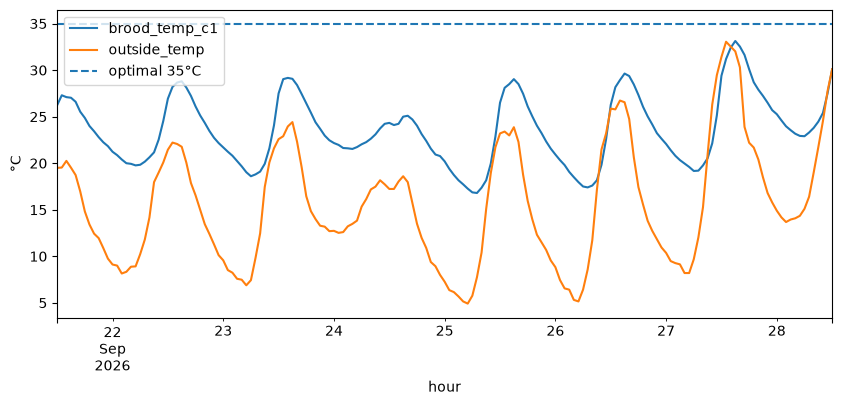

In [198]:
# TODO: plot brood vs outside temperature for one hive.
import matplotlib.pyplot as plt

OPTIMAL_C = 35  # brood-nest target
DAYS = 7        # try 3; comment out the window line for the full extract

one = features[features["beehive_id"] == 1]
window = one[one["hour"] >= one["hour"].max() - pd.Timedelta(days=DAYS)]

ax = window.plot(x="hour", y=["brood_temp_c1", "outside_temp"], figsize=(10, 4))
ax.axhline(OPTIMAL_C, linestyle="--", label=f"optimal {OPTIMAL_C}°C")
ax.set_ylabel("°C")
ax.legend() #3

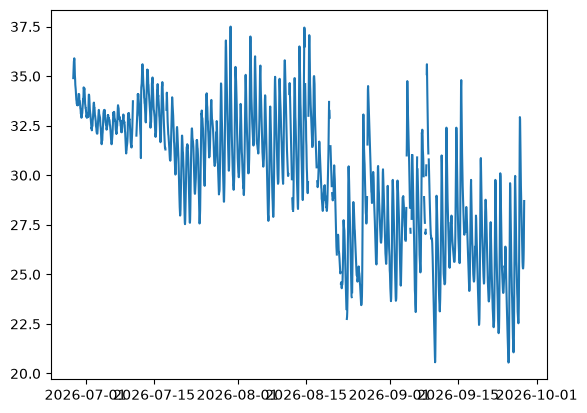

In [205]:
hive_2_data = features[features["beehive_id"] == 2]
fig = plt.plot(hive_2_data["hour"], hive_2_data["brood_temp_c2"]) #1

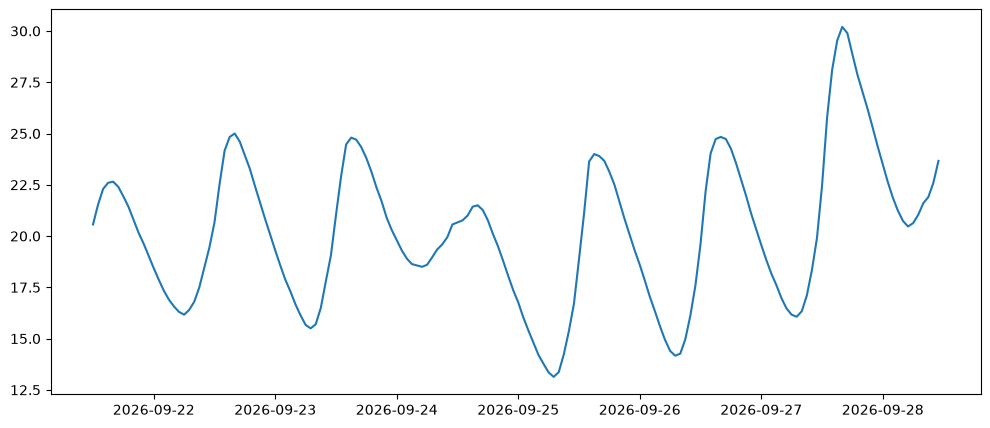

In [206]:
DAYS = 7
data_7_days_plot = hive_2_data[hive_2_data["hour"] >= max(hive_2_data["hour"]) - pd.Timedelta(days=DAYS)]
plot_data = ...
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(..., ...) #2

In [222]:
temp = features[["beehive_id", "hour", "brood_temp_c2", "brood_temp_c1", "brood_temp_c3", "outside_temp"]]
temp_7_days = temp[temp["hour"] >= max(temp["hour"]) - pd.Timedelta(days=DAYS)]

In [210]:
import seaborn as sns

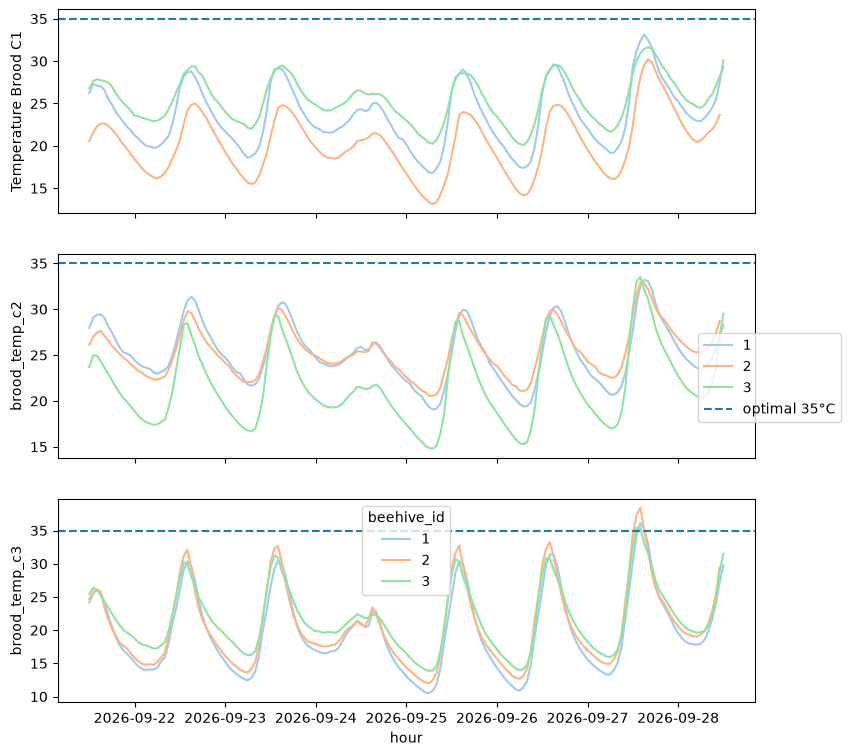

In [247]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True,)

for ax in axes:
    sns.lineplot(
        data=...,
        x="...",
        y=f"brood_temp_c{ax+1}",
        hue="...",
        palette="...",
        ax=ax,
    )
    ax.set_ylabel(f"Temperature Brood C{ax+1}")
    ax.axhline(OPTIMAL_C, linestyle="--", label=f"optimal {OPTIMAL_C}°C")
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='right') #5

<Axes: xlabel='hour', ylabel='brood_temp_c3'>

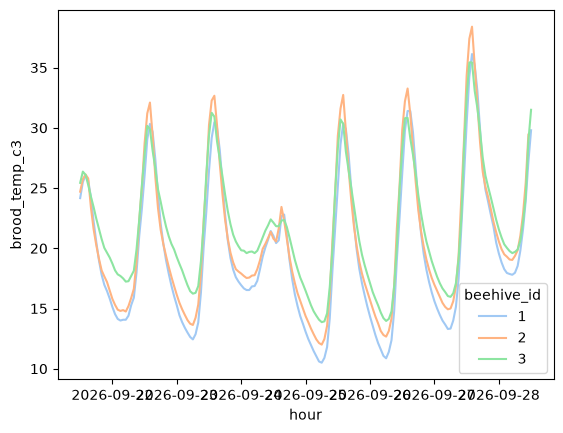

In [230]:
sns.lineplot(data=temp_7_days, x="...", y="...", hue="beehive_id", palette="pastel") #4